# Download Satellite Heat Detection Data from the SCIL AIC:W Sythetic Constellation API
### What this notebook does:

1. Search for Satellite heat detections by datetime range
2. Download detection features from the SCIL AIC:W API
3. Visualize heat detections on a Folium map
4. Save as JSON and PNG


### Data source:

* SCIL AIC:W API
* Layers: 
	- fire_detections_all (past 30 days)
	- fire_detections_all_archive (full timespan)
	- fire_detections_grid (density map)
	- fire_detections_landsat
	- fire_detections_meteosat_iodc
	- fire_detections_meteosat_msg
	- fire_detections_modis
	- fire_detections_ngfs_goes_east
	- fire_detections_ngfs_goes_west
	- fire_detections_sentinel3
	- fire_detections_viirs_noaa20
	- fire_detections_viirs_noaa21
	- fire_detections_viirs_snpp

* Contains both individual member and combined detections with global coverage and common timestamps:
	https://sparcal.sdsc.edu/geoserver/web/?13&workspace=aicw

* Note: the earliest available detections start from 2026-07-22 onwards

### Requirements:

* Internet connection
* Fire name
* Bounding Box (BBOX)
* Fire start/stop datetimes

<!-- View this data in action on the UC San Diego SCIL Satellite Fire Detection Dashboard:  -->
<!-- https://aicw.wildfirecommons.org/detection-dashboard -->

# Dependencies

In [1]:
import requests
import json
import sys
from datetime import datetime, timezone
import folium
import os

# Fire Data Collection


Testing the Geoserver API Query

In [2]:
# ========== USER INPUTS ==========

fire_name = "Sorrento"  # Your chosen fire name will be used for download's folder and filename

layer = "fire_detections_all_archive"  # Choose your layer(s) from the list above
style = ""  # Optional - Choose your layers' corresponding style
limit = '1000'  # Optional - Limits the number of features returned - max is 10000

# Bounding Box
	# Syntax: "LowerLeft_Longitude,LowerLeft_Latitude,UpperRight_Longitude,UpperRight_Latitude,'EPSG:Code'"
	# For a complete CA BBOX, enter: "-124.5,32.45,-114.0,42.10,'EPSG:4326'"
LL_lon = -117.31181452
LL_lat = 32.84193601
UR_lon = -117.02771324
UR_lat = 32.99261321
bbox = f"{LL_lon},{LL_lat},{UR_lon},{UR_lat}"
map_center = [(LL_lat+UR_lat)/2.0, (LL_lon+UR_lon)/2.0]

# WMS image size calculation	
	# Calculate degree spans
dx = UR_lon - LL_lon
dy = UR_lat - LL_lat
	# Set a fixed base width and scale height by the aspect ratio
base_width = 800
aspect_ratio = dy / dx
width = base_width
height = int(base_width * aspect_ratio)

# Specify the fire's datetime (yyyy, m, d, h, m, s)
dt_start = datetime(2026, 8, 16, 0, 0, 1)  # Note: the earliest available detection starts from (2026, 7, 22, 0, 0, 1)
dt_end = datetime(2026, 8, 18, 23, 59, 59)  # Note: Large datetime ranges (ex: more than 1 year) may overtax your computer's resources
print(dt_start)

# Convert datetime to UTC
dt_start_utc = dt_start.astimezone(timezone.utc).isoformat(sep='T').replace('+00:00', 'Z')
dt_end_utc = dt_end.astimezone(timezone.utc).isoformat(sep='T').replace('+00:00', 'Z')
print(dt_start_utc)
# ==================================

2026-08-16 00:00:01
2026-08-16T07:00:01Z



Create Output Filename & Directory

In [3]:
# Set Output folder & filename prefix
filename = fire_name.replace(" ", "_")
os.makedirs(f"./Fires/{filename}", exist_ok=True)

timestamp = dt_start_utc.replace(":", "")

print(f"Output folder: {filename}")
print(f"Timestamp: {timestamp}")

Output folder: Sorrento
Timestamp: 2026-08-16T070001Z


Fire Detection Query - OGC Features  
https://sparcal.sdsc.edu/geoserver/aicw/ogc/features/v1/openapi?f=text%2Fhtml#/

###### Displayed with FRP-based styling 

In [4]:
# GeoServer OGC Features URL configuration
ogcf_url = f"https://sparcal.sdsc.edu/geoserver/aicw/ogc/features/v1/collections/{layer}/items?"
ogcf_params = {
    # 'limit': limit,  # Uncomment to activate limit value
    'datetime': f'{dt_start_utc}/{dt_end_utc}',
    'bbox': bbox,
	# 'filter': "sensor = 'VIIRS' AND frp > 10 ",  # Create a CQL filter here
	'filter-lang': 'cql2-text',
    'f': 'json',
	'sortby': 'age_hours'
}

# Request the data
ogcf_r = requests.get(ogcf_url, params=ogcf_params, timeout=60)
print(ogcf_r.url)
if ogcf_r.status_code != 200:
    print(ogcf_r.status_code)
    print(ogcf_r.text)
    # sys.exit(1)

ogcf_j = ogcf_r.json()
ogcf_f = ogcf_j.get("features", [])

print(f"✓ Found {len(ogcf_f)} {layer} detections \n")

# View the JSON
print(json.dumps(ogcf_j,indent=2))   # WARNING: Large datetime ranges may overtax your computer's resources

if not ogcf_f:
    raise ValueError(
        f"No {layer} dections found for '{fire_name}'.\n"
        f"Check that the Check that the layer name, BBOX coords, and datetime range are valid.\n"
    )

# Create map object
ogcf_m = folium.Map(location=map_center, tiles='cartodbpositron', zoom_start=11)

	# Add Circle Marker for GeoJson features
ogcf_features = folium.GeoJson(ogcf_j,
    name=f"{layer}_OGCFeatures",
	marker=folium.Circle(),
     style_function=lambda feature: {
        "radius": feature["properties"]["frp"],  # Radius by FRP
		"color": "red",
        "fill": True,
        "fill_color": "red",
        "fill_opacity": 0.1},
	tooltip=folium.GeoJsonTooltip(
		fields=['id','detection_dt','sensor_collection','sensor','platform','instrument','detection_tier','frp'])
).add_to(ogcf_m)

# Add layer control to toggle the combined visualization
folium.LayerControl().add_to(ogcf_m)

# Save or display the map
ogcf_m.save(f"./Fires/{filename}/{fire_name}_{layer}_{timestamp}_ogcf.html")  # Uncomment to Save webmap
ogcf_m  # Uncomment to Display webmap

https://sparcal.sdsc.edu/geoserver/aicw/ogc/features/v1/collections/fire_detections_all_archive/items?datetime=2026-08-16T07%3A00%3A01Z%2F2026-08-19T06%3A59%3A59Z&bbox=-117.31181452%2C32.84193601%2C-117.02771324%2C32.99261321&filter-lang=cql2-text&f=json&sortby=age_hours
✓ Found 102 fire_detections_all_archive detections 

{
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "id": "fire_detections_all_archive.126d431fab484561",
      "geometry": {
        "type": "Point",
        "coordinates": [
          -117.02958,
          32.85515
        ]
      },
      "geometry_name": "geom",
      "properties": {
        "id": "126d431fab484561",
        "detection_dt": "2026-08-18T08:56:00Z",
        "sensor_collection": "firms-viirs-noaa21-nrt",
        "sensor": "VIIRS",
        "platform": "N21",
        "instrument": "VIIRS",
        "detection_tier": "NRT",
        "frp": 0.41,
        "confidence_pct": 55,
        "daynight": "N",
        "scan": 0.35,

In [5]:
# # For full Traceback 
# %tb

Previewing the OGC Features JSON response in GIS with satellite-based styling

In [6]:
# Create map object
m = folium.Map(location=map_center, tiles='cartodbpositron', zoom_start=11)

try:
	# GOES
		# Filter for objects where 'id' contains the partial string 'view_modis'
	search_goes = "GOES"
	goes_subset = [feat for feat in ogcf_j['features'] if search_goes in feat['properties']['sensor']]
		# Create new GeoJSON structure
	goes_geojson = {
		"type": "FeatureCollection",
		"features": goes_subset}
	# print(goes_geojson)

	if len(goes_geojson.get("features", [])) < 1:
		print(f"No GOES dections found.\n" )
	

	else:
		# Add 1000m Radius Circle Marker for GOES GeoJson features
		goes_features = folium.GeoJson(goes_geojson,
			name="GOES",
			marker=folium.Circle(
				radius=1000, # Radius in meters
				color="blue",
				fill=True,
				fill_color="blue",
				fill_opacity=0.01),
			tooltip=folium.GeoJsonTooltip(
				fields=['id','detection_dt','sensor_collection','sensor','platform','instrument','detection_tier','frp'])
		).add_to(m)
except:
	print(f"Creation of '{fire_name}' {layer} GOES layer unsuccessful.\n Check that the Check that the layer name(s), BBOX coords, and datetime range are valid.\n")

try:
	# MODIS
		# Filter for objects where 'id' contains the partial string 'view_modis'
	search_modis = "MODIS"
	modis_subset = [feat for feat in ogcf_j['features'] if search_modis in feat['properties']['sensor']]
		# Create new GeoJSON structure
	modis_geojson = {
		"type": "FeatureCollection",
		"features": modis_subset}
	# print(modis_geojson)

	if len(modis_geojson.get("features", [])) < 1:
		print(f"No MODIS dections found.\n" )
	

	else:
		# Add 500m Radius Circle Marker for MODIS GeoJson features
		modis_features = folium.GeoJson(modis_geojson,
			name="MODIS",
			marker=folium.Circle(
				radius=500, # Radius in meters
				color="green",
				fill=True,
				fill_color="green",
				fill_opacity=0.2),
			tooltip=folium.GeoJsonTooltip(
				fields=['id','detection_dt','sensor_collection','sensor','platform','instrument','detection_tier','frp'])
		).add_to(m)
except:
	print(f"Creation of '{fire_name}' {layer} MODIS layer unsuccessful.\n Check that the Check that the layer name(s), BBOX coords, and datetime range are valid.\n")

try:
	# VIIRS
		# Filter for objects where 'id' contains the partial string 'view_viirs'
	search_viirs = "VIIRS"
	viirs_subset = [feat for feat in ogcf_j['features'] if search_viirs in feat['properties']['sensor']]
		# Create new GeoJSON structure
	viirs_geojson = {
		"type": "FeatureCollection",
		"features": viirs_subset}
	# print(viirs_geojson)

	if len(viirs_geojson.get("features", [])) < 1:
		print(f"No VIIRS dections found.\n" )
	

	else:
		# Add 200m Radius Circle Marker for VIIRS GeoJson features
		viirs_features = folium.GeoJson(viirs_geojson,
			name="VIIRS",
			marker=folium.Circle(
				radius=200, # Radius in meters
				color="red",
				fill=True,
				fill_color="red",
				fill_opacity=0.2),
			tooltip=folium.GeoJsonTooltip(
				fields=['id','detection_dt','sensor_collection','sensor','platform','instrument','detection_tier','frp'])
		).add_to(m)
except:
	print(f"Creation of '{fire_name}' {layer} VIIRS layer unsuccessful.\n Check that the Check that the layer name(s), BBOX coords, and datetime range are valid.\n")

try:
	# LANDSAT
		# Filter for objects where 'id' contains the partial string 'view_viirs'
	search_landsat = "LANDSAT"
	landsat_subset = [feat for feat in ogcf_j['features'] if search_landsat in feat['properties']['sensor']]
		# Create new GeoJSON structure
	landsat_geojson = {
		"type": "FeatureCollection",
		"features": landsat_subset}
	# print(landsat_geojson)

	if len(landsat_geojson.get("features", [])) < 1:
		print(f"No LANDSAT dections found.\n" )
	

	else:
		# Add 200m Radius Circle Marker for LANDSAT GeoJson features
		landsat_features = folium.GeoJson(landsat_geojson,
			name="LANDSAT",
			marker=folium.Circle(
				radius=100, # Radius in meters
				color="orange",
				fill=True,
				fill_color="orange",
				fill_opacity=0.2),
			tooltip=folium.GeoJsonTooltip(
				fields=['id','detection_dt','sensor_collection','sensor','platform','instrument','detection_tier','frp'])
		).add_to(m)
except:
	print(f"Creation of '{fire_name}' {layer} LANDSAT layer unsuccessful.\n Check that the Check that the layer name(s), BBOX coords, and datetime range are valid.\n")

# Add Layer Control to Toggle Layers
folium.LayerControl().add_to(m)

# Preview map
m   # WARNING: Large datetime ranges may overtax your computer's resources

No MODIS dections found.

No LANDSAT dections found.



Downloading OGC Features JSON

In [7]:
# GeoServer OGC Features URL JSON configuration
url = f"https://sparcal.sdsc.edu/geoserver/aicw/ogc/features/v1/collections/{layer}/items?"
params = {
    'limit': limit,  # Uncomment to activate limit value
    'datetime': f'{dt_start_utc}/{dt_end_utc}',
    'bbox': bbox,
	# 'filter': "sensor = 'VIIRS' AND frp > 10 ",  # Create a CQL filter here
	'filter-lang': 'cql2-text',
    'f': 'json',
	# 'sortby': 'age_hours'
}

r = requests.get(url, params=params, timeout=60)
if r.status_code != 200:
    print(r.text)
    sys.exit(1)
elif r.status_code == 200:
    j = r.json()    
    with open(f"./Fires/{filename}/{filename}_{layer}_{timestamp}_ogcf.json", "w", encoding="utf-8") as file:
        json.dump(j, file)
    print("AIC:W OGC Features JSON saved successfully.")
else:
    print("Error:", r.status_code, r.text)

AIC:W OGC Features JSON saved successfully.


Fire Detection Query - WMS

Map image downloaded.
Status code: 200
https://sparcal.sdsc.edu/geoserver/aicw/ows?service=WMS&version=1.3.0&request=GetMap&layers=fire_detections_all_archive&crs=CRS%3A84&bbox=-117.31181452%2C32.84193601%2C-117.02771324%2C32.99261321&width=800&height=424&format=image%2Fpng&time=2026-08-16T07%3A00%3A01Z%2F2026-08-19T06%3A59%3A59Z



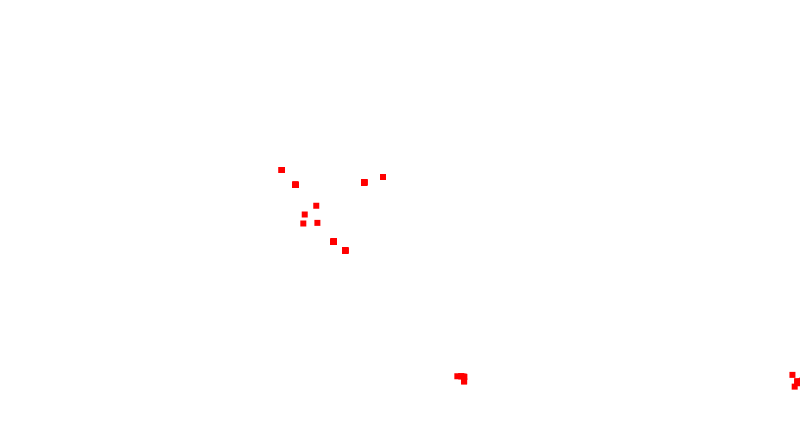

In [8]:
wms_url = f"https://sparcal.sdsc.edu/geoserver/aicw/ows?"
wms_params = {
    'service': 'WMS',
    'version': '1.3.0',	# Select version: 1.3.0 ; 1.1.1
    'request': 'GetMap',
    'layers': layer,
    'crs': 'CRS:84',
    'bbox': bbox,
    'width': width,
    'height': height,
    'format': 'image/png',
    'time': f'{dt_start_utc}/{dt_end_utc}'
}

# Request the map
wms_r = requests.get(wms_url, params=wms_params, timeout=60)

# Save the map image
if wms_r.status_code == 200:
    with open(f"./Fires/{filename}/{filename}_{layer}_{timestamp}_wms.png", "wb") as f:  # Uncomment to save a copy of the image
        f.write(wms_r.content)
        print("Map image downloaded.")
        print(f"Status code: {wms_r.status_code}")
        print(wms_r.url)
else:
    print(f"Failed to fetch map layer '{layer}' for '{fire_name}'. Status code: {wms_r.status_code}\n")
    print("Check that the Check that the layer name(s), BBOX coords, and datetime range are valid.\n")

# View the downloaded map
raster_m = folium.Map(location=map_center, tiles='cartodbpositron', zoom_start=10)

# Add image overlay with specific corner bounds [[lat_min, lon_min], [lat_max, lon_max]]
folium.raster_layers.ImageOverlay(
    image=f"./Fires/{filename}/{filename}_{layer}_{timestamp}_wms.png",
    bounds=[[LL_lat, LL_lon],[UR_lat, UR_lon]],
    opacity=0.5
).add_to(raster_m)

# Preview map
raster_m

View Current WMS Detections

In [9]:
# View the map
wms_url = "https://sparcal.sdsc.edu/geoserver/aicw/ows?"

wms_m = folium.Map(location=map_center, tiles='cartodbpositron', zoom_start=8)

# Layer 1: Satellite Detections (Zoomed in)
folium.WmsTileLayer(
    url=wms_url,
    layers="fire_detections_all",
    fmt="image/png",
    transparent=True,
    name="fire_detections_all",
    overlay=True,
    show=True  # Displayed by default
).add_to(wms_m)

# Layer 2: Desnisty Grid (Zoomed out)
folium.WmsTileLayer(
    url=wms_url,
    layers="fire_detections_grid",
    fmt="image/png",
    transparent=True,
    name="fire_detections_grid",
    overlay=True,
    show=True  # Displayed by default
).add_to(wms_m)

# Add layer control to toggle the combined visualization
folium.LayerControl().add_to(wms_m)

# Save or display the map
wms_m.save(f"./Fires/{filename}/{fire_name}_{layer}_{timestamp}_wms.html")  # Uncomment to Save webmap
wms_m  # Uncomment to Display webmap

Data Visualization Example: Animating Satellite Detections Time-lapse 
- See a demonstration visualizing this and other fire data via the UC San Diego SCIL Satellite Fire Detection Dashboard: 
https://aicw.wildfirecommons.org/detection-dashboard

VIIRS
![Alt Text](https://aicw.wildfirecommons.org/googleai/satellites/Border2_Viirs.gif)


MODIS
![Alt Text](https://aicw.wildfirecommons.org/googleai/satellites/Border2_Modis.gif)


GOES
![Alt Text](https://aicw.wildfirecommons.org/googleai/satellites/Border2_Goes.gif)


Combined
![Alt Text](https://aicw.wildfirecommons.org/googleai/satellites/Border2_All.gif)